# Report analysis
```
Name: Amey Hengle
Email: ameyhen@umd.edu
UID: 
```

- Checks for the report using more queries than the 9 in the main notebook: the same 9 queries plus 300 random queries per genre (908 in total). I also use pretrained GloVe vectors as a reference for what an embedding trained on a lot more text does
- Figures and plots are saved to `figures/` 
- Additional results are in `additional_results.ipynb`.

## Setup

In [1]:
import re, time, itertools, logging, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse, stats
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec
from gensim.test.utils import datapath
import gensim.downloader as api
logging.getLogger("gensim").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.titleweight": "bold",
                     "axes.titlesize": 11, "axes.labelsize": 10})

SEED = 42
DATA_FILE = "emotion_multigenre_corpus_setences.txt"
CLAUSE_FILE = "emotion_multigenre_corpus_clauses.txt"
STOPLIST = "mallet_en_stoplist.txt"
GENRES = ["newsheadline", "moviereview", "blog"]
K, K_MAX = 10, 50
N_EVAL_PER_GENRE = 300
N_REPEATS = 30
N_BOOT = 2000
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

METHODS = ["one-hot", "tf-idf", "word2vec"]
REF = "GloVe (pretrained)"
ALL_M = METHODS + [REF]
MC = {"one-hot": "#4C72B0", "tf-idf": "#DD8452", "word2vec": "#55A868", REF: "#9A9A9A"}
GC = {"newsheadline": "#8172B3", "moviereview": "#C44E52", "blog": "#3A9BBF"}
POLARITY = {"joy": "positive", "trust": "positive", "anger": "negative", "disgust": "negative",
            "fear": "negative", "sadness": "negative", "noemotion": "neutral"}
P_LIST = ["positive", "negative", "neutral", "ambiguous"]

def save(fig, name):
    # save a figure to figures/
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")

In [2]:
def load_corpus(path):
    # last three tab-separated fields are text, emotion, genre
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 4:
                rows.append({"text": parts[-3].strip(), "emotion": parts[-2], "genre": parts[-1]})
    return pd.DataFrame(rows)

with open(STOPLIST, encoding="utf-8") as f:
    STOPWORDS = set(w.strip() for w in f if w.strip())
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
PTB_BRACKETS = re.compile(r"-[LR][RSC]B-")

def tokenize(text):
    # same preprocessing as the main notebook
    return [t for t in TOKEN_RE.findall(PTB_BRACKETS.sub(" ", text).lower())
            if t not in STOPWORDS and len(t) > 1 and "'" not in t]

df = load_corpus(DATA_FILE)
df["tokens"] = df.text.apply(tokenize)
df = df[df.tokens.str.len() > 0].drop_duplicates(subset="text").reset_index(drop=True)
df["n_tok"] = df.tokens.str.len()
df["polarity"] = df.emotion.map(POLARITY).fillna("ambiguous")
N = len(df)

E_LIST = sorted(df.emotion.unique())
GENRE_BASE = df.genre.value_counts(normalize=True).reindex(GENRES)
COND_POL = pd.crosstab(df.genre, df.polarity, normalize="index").reindex(index=GENRES, columns=P_LIST).fillna(0).to_numpy()
COND_EMO = pd.crosstab(df.genre, df.emotion, normalize="index").reindex(index=GENRES, columns=E_LIST).fillna(0).to_numpy()
MR = GENRES.index("moviereview")
POS, NEG = P_LIST.index("positive"), P_LIST.index("negative")
pn = df[(df.genre == "moviereview") & df.polarity.isin(["positive", "negative"])].polarity.value_counts(normalize=True)
MR_CHANCE = float((pn ** 2).sum())
print(N, "sentences")

16822 sentences


GloVe (`glove-wiki-gigaword-100`, about 128 MB) is downloaded the first time.

In [3]:
identity = lambda x: x

def l2(X):
    # row-normalize so cosine = dot product
    return normalize(X) if sparse.issparse(X) else normalize(np.asarray(X, dtype=np.float64))

def enc_onehot(tl):
    # binary bag of words
    return CountVectorizer(analyzer=identity, binary=True).fit_transform(tl)

def enc_tfidf(tl, fit_on=None):
    # tf-idf, optionally fitted on a different set of sentences
    vec = TfidfVectorizer(analyzer=identity).fit(fit_on if fit_on is not None else tl)
    return vec.transform(tl), vec

def train_w2v(tl, seed=SEED, epochs=None):
    # skip-gram Word2Vec, more epochs for small corpora
    n = len(tl)
    if epochs is None:
        epochs = 50 if n < 1000 else (30 if n < 5000 else 20)
    return Word2Vec(sentences=tl, vector_size=100, window=5, min_count=1, sg=1,
                    epochs=epochs, workers=1, seed=seed)

def mean_vectors(tl, kv, dim=100):
    # sentence vector = mean of known word vectors
    X = np.zeros((len(tl), dim))
    for i, toks in enumerate(tl):
        v = [kv[w] for w in toks if w in kv.key_to_index]
        if v:
            X[i] = np.mean(v, axis=0)
    return X

TL = df.tokens.tolist()
X_oh = enc_onehot(TL)
X_tf, TFVEC = enc_tfidf(TL)
W2V_FULL = train_w2v(TL)
GLOVE = api.load("glove-wiki-gigaword-100")

FULL = {"one-hot": l2(X_oh), "tf-idf": l2(X_tf),
        "word2vec": l2(mean_vectors(TL, W2V_FULL.wv)), REF: l2(mean_vectors(TL, GLOVE))}

## Retrieval helpers and metrics
- same-genre share of the top 10
- sentiment match adjusted for genre (emotion labels depend a lot on genre in this corpus)
- relatedness judged by GloVe: 0 = random, 1 = GloVe's own top 10

In [4]:
def pick_queries(frame, n=3, min_tokens=3, seed=SEED):
    # n random queries per genre (same rule as the main notebook)
    picks = []
    for g in [g for g in GENRES if g in set(frame.genre)]:
        pool = frame[(frame.genre == g) & (frame.tokens.str.len() >= min_tokens)]
        picks += pool.sample(n, random_state=seed).index.tolist()
    return picks

def topk_search(mats, q_idx, k=K_MAX, chunk=128):
    # top-k neighbours per query and method, plus how many candidates tie with the 10th score
    q_idx = np.asarray(q_idx)
    out = {}
    for m, X in mats.items():
        n = X.shape[0]
        kk = min(k, n - 1)
        idx = np.empty((len(q_idx), kk), dtype=np.int64)
        sc = np.empty((len(q_idx), kk))
        tied = np.empty(len(q_idx), dtype=np.int64)
        for s in range(0, len(q_idx), chunk):
            qs = q_idx[s:s + chunk]
            sim = X[qs] @ X.T
            sim = sim.toarray() if sparse.issparse(sim) else np.asarray(sim)
            sim = sim.astype(np.float64)
            sim[np.arange(len(qs)), qs] = -np.inf
            order = np.argsort(-sim, axis=1, kind="stable")[:, :kk]
            top = np.take_along_axis(sim, order, axis=1)
            idx[s:s + len(qs)], sc[s:s + len(qs)] = order, top
            kth = top[:, min(K, kk) - 1][:, None]
            tied[s:s + len(qs)] = np.isclose(sim, kth, rtol=0, atol=1e-9).sum(axis=1)
        out[m] = {"idx": idx, "score": sc, "tied_at_k": tied}
    return out

def make_meta(frame, glove_mat):
    # labels and GloVe vectors needed for the metrics
    return {"g": pd.Categorical(frame.genre, categories=GENRES).codes,
            "p": pd.Categorical(frame.polarity, categories=P_LIST).codes,
            "e": pd.Categorical(frame.emotion, categories=E_LIST).codes,
            "toks": [set(t) for t in frame.tokens], "ntok": frame.n_tok.to_numpy(), "glove": glove_mat}

def per_query_metrics(res, q_idx, meta, k=K, rand_n=500, seed=SEED):
    # one row per query and method with all metrics at k
    q_idx = np.asarray(q_idx)
    n = len(meta["g"])
    gq, pq, eq = meta["g"][q_idx], meta["p"][q_idx], meta["e"][q_idx]
    Gv = meta["glove"]
    if n - 1 <= rand_n:
        S = Gv[q_idx] @ Gv.T
        S[np.arange(len(q_idx)), q_idx] = np.nan
        rand = np.nanmean(S, axis=1)
    else:
        R = np.random.default_rng(seed).choice(n, rand_n, replace=False)
        rand = (Gv[q_idx] @ Gv[R].T).mean(axis=1)
    frames = []
    for m, r in res.items():
        top = r["idx"][:, :k]
        sc = r["score"][:, :k]
        gt = meta["g"][top]
        pol_match = meta["p"][top] == pq[:, None]
        mr_ret = (gt == MR) & np.isin(meta["p"][top], [POS, NEG])
        jac = np.array([[len(meta["toks"][q] & meta["toks"][t]) / len(meta["toks"][q] | meta["toks"][t]) for t in row]
                        for q, row in zip(q_idx, top)])
        judge = np.einsum("qkd,qd->qk", Gv[top], Gv[q_idx]).mean(axis=1)
        if r["score"].shape[1] > k:
            boundary_tie = np.isclose(r["score"][:, k - 1], r["score"][:, k], rtol=0, atol=1e-9)
        else:
            boundary_tie = np.zeros(len(q_idx), bool)
        frames.append(pd.DataFrame({
            "method": m, "q": q_idx, "q_genre": np.array(GENRES)[gq], "q_pol": np.array(P_LIST)[pq],
            "same_genre": (gt == gq[:, None]).mean(1),
            "pol_obs": pol_match.sum(1), "pol_exp": COND_POL[gt, pq[:, None]].sum(1),
            "emo_obs": (meta["e"][top] == eq[:, None]).sum(1), "emo_exp": COND_EMO[gt, eq[:, None]].sum(1),
            "mr_n": mr_ret.sum(1), "mr_same": (pol_match & mr_ret).sum(1),
            "jaccard": jac.mean(1), "no_shared_word": (jac == 0).mean(1),
            "judge": judge, "rand": rand, "glove_ok": np.linalg.norm(Gv[q_idx], axis=1) > 0,
            "q_len": meta["ntok"][q_idx], "ret_len": meta["ntok"][top].mean(1),
            "score_mean": sc.mean(1), "zero_slots": (sc == 0).mean(1),
            "boundary_tie": boundary_tie, "tied_at_k": r["tied_at_k"]}))
    return pd.concat(frames, ignore_index=True)

def boot_mean(x, n=N_BOOT, seed=SEED):
    # mean with 95% bootstrap CI over queries
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    I = np.random.default_rng(seed).integers(0, len(x), (n, len(x)))
    lo, hi = np.percentile(x[I].mean(1), [2.5, 97.5])
    return x.mean(), lo, hi

def boot_ratio(num, den, n=N_BOOT, seed=SEED):
    # ratio of sums with 95% bootstrap CI over queries
    num, den = np.asarray(num, float), np.asarray(den, float)
    I = np.random.default_rng(seed).integers(0, len(num), (n, len(num)))
    lo, hi = np.percentile(num[I].sum(1) / den[I].sum(1), [2.5, 97.5])
    return num.sum() / den.sum(), lo, hi

def norm_judge(pqm, n=N_BOOT, seed=SEED):
    # GloVe relatedness scaled so random = 0 and GloVe's own top 10 = 1
    piv = pqm[pqm.glove_ok].pivot_table(index="q", columns="method", values="judge")
    rnd = pqm[pqm.glove_ok].groupby("q").rand.first().reindex(piv.index).to_numpy()
    I = np.random.default_rng(seed).integers(0, len(piv), (n, len(piv)))
    out = {}
    for m in piv.columns:
        f = lambda ix: (piv[m].to_numpy()[ix].mean(-1) - rnd[ix].mean(-1)) / (piv[REF].to_numpy()[ix].mean(-1) - rnd[ix].mean(-1))
        out[m] = (f(np.arange(len(piv))), *np.percentile(f(I), [2.5, 97.5]))
    return out

def small_setting(sub, w2v_seed=SEED):
    # encode a small sample on its own and use every sentence as a query
    sub = sub.reset_index(drop=True)
    tl = sub.tokens.tolist()
    mats = {"one-hot": l2(enc_onehot(tl)), "tf-idf": l2(enc_tfidf(tl)[0]),
            "word2vec": l2(mean_vectors(tl, train_w2v(tl, seed=w2v_seed).wv)), REF: l2(mean_vectors(tl, GLOVE))}
    q = np.arange(len(sub))
    res = topk_search(mats, q, k=K + 1)
    return per_query_metrics(res, q, make_meta(sub, mats[REF])), res, mats

def summarize(pqm):
    # one row of summary metrics per method
    rows = {}
    for m, d in pqm.groupby("method"):
        pol = d[d.q_pol.isin(["positive", "negative"])]
        mrq = pol[pol.q_genre == "moviereview"]
        rows[m] = {"same_genre": d.same_genre.mean(),
                   "pol_lift_adj": pol.pol_obs.sum() / pol.pol_exp.sum(),
                   "mr_sentiment": mrq.mr_same.sum() / max(mrq.mr_n.sum(), 1),
                   "zero_slots": d.zero_slots.mean(), "jaccard": d.jaccard.mean()}
    nj = norm_judge(pqm, n=200)
    for m in rows:
        rows[m]["norm_judge"] = nj[m][0]
    return pd.DataFrame(rows).T

## Full corpus, 908 queries

In [5]:
SHOW_Q = pick_queries(df)
EVAL_Q = np.array(list(dict.fromkeys(pick_queries(df, n=N_EVAL_PER_GENRE, seed=SEED + 1) + SHOW_Q)))
RES_FULL = topk_search(FULL, EVAL_Q)
META_FULL = make_meta(df, FULL[REF])
PQ_FULL = per_query_metrics(RES_FULL, EVAL_Q, META_FULL)
PQ_FULL["showcase"] = PQ_FULL.q.isin(SHOW_Q)
print(len(EVAL_Q), "queries")

908 queries


## Experiment 2 repeated
30 random 100/genre samples. The first one is the sample used in the main notebook.

In [6]:
rep_rows = []
STATES = [SEED] + list(range(1000, 1000 + N_REPEATS - 1))
for rs in STATES:
    sample = df.groupby("genre").sample(100, random_state=rs)
    sep = pd.concat([small_setting(sample[sample.genre == g])[0] for g in GENRES], ignore_index=True)
    pooled = small_setting(sample)[0]
    for setting, pqm in [("100/genre (separate)", sep), ("300 pooled", pooled)]:
        s = summarize(pqm)
        s["setting"] = setting
        s["random_state"] = rs
        rep_rows.append(s.rename_axis("method").reset_index())
REP = pd.concat(rep_rows, ignore_index=True)
REP["your_sample"] = REP.random_state == SEED
REP.groupby(["setting", "method"])[["same_genre", "pol_lift_adj", "mr_sentiment", "zero_slots", "norm_judge"]].mean().round(3)

same_genre  pol_lift_adj  \
setting              method                                         
100/genre (separate) GloVe (pretrained)       1.000         1.184   
                     one-hot                  1.000         1.038   
                     tf-idf                   1.000         1.040   
                     word2vec                 1.000         1.089   
300 pooled           GloVe (pretrained)       0.588         1.198   
                     one-hot                  0.434         1.058   
                     tf-idf                   0.432         1.061   
                     word2vec                 0.408         1.079   

                                         mr_sentiment  zero_slots  norm_judge  
setting              method                                                    
100/genre (separate) GloVe (pretrained)         0.537       0.003       1.000  
                     one-hot                    0.508       0.767       0.386  
                     tf-idf                     0.509       0.767       0.387  
                     word2vec                   0.515       0.000       0.552  
300 pooled           GloVe (pretrained)         0.541       0.003       1.000  
                     one-hot                    0.530       0.635       0.223  
                     tf-idf                     0.531       0.635       0.224  
                     word2vec                   0.517       0.000       0.447

## Learning curve
Each encoder is fitted on N sentences only, then used on the same 908 queries over the full corpus.

In [7]:
SIZES = [300, 1000, 3000, 10000, N]
WS353 = datapath("wordsim353.tsv")
pr = np.random.default_rng(99).choice(N, (20000, 2))
PAIRS = pr[pr[:, 0] != pr[:, 1]]
SHARED = np.asarray(FULL["tf-idf"][PAIRS[:, 0]].multiply(FULL["tf-idf"][PAIRS[:, 1]]).sum(1)).ravel() > 0

lc_rows = []
for size in SIZES:
    for s in range(3):
        rng = np.random.default_rng(s)
        train_idx = rng.choice(N, size, replace=False) if size < N else rng.permutation(N)
        tl_train = [TL[i] for i in train_idx]
        model = train_w2v(tl_train, seed=s)
        cv = CountVectorizer(analyzer=identity, binary=True).fit(tl_train)
        mats = {"one-hot": l2(cv.transform(TL)), "tf-idf": l2(enc_tfidf(TL, fit_on=tl_train)[0]),
                "word2vec": l2(mean_vectors(TL, model.wv)), REF: FULL[REF]}
        summ = summarize(per_query_metrics(topk_search(mats, EVAL_Q, k=K + 1), EVAL_Q, META_FULL))
        ws = model.wv.evaluate_word_pairs(WS353)
        known = np.mean([any(w in model.wv.key_to_index for w in t) for t in TL])
        W = mats["word2vec"]
        wc = (W[PAIRS[:, 0]] * W[PAIRS[:, 1]]).sum(1)
        ok = (np.linalg.norm(W[PAIRS[:, 0]], axis=1) > 0) & (np.linalg.norm(W[PAIRS[:, 1]], axis=1) > 0)
        a, b = wc[ok & SHARED], wc[ok & ~SHARED]
        lex_auc = stats.mannwhitneyu(a, b).statistic / (len(a) * len(b))
        for m in summ.index:
            w2v = m == "word2vec"
            lc_rows.append({"size": size, "seed": s, "tokens": sum(len(t) for t in tl_train), "method": m,
                            **summ.loc[m].to_dict(), "sentences_with_known_word": known,
                            "ws_spearman": ws[1][0] if w2v else np.nan, "ws_oov": ws[2] if w2v else np.nan,
                            "lexical_auc": lex_auc if w2v else np.nan, "mean_pair_cos": wc[ok].mean() if w2v else np.nan})
LC = pd.DataFrame(lc_rows)
GLOVE_WS = GLOVE.evaluate_word_pairs(WS353)
print("GloVe WordSim353 Spearman:", round(GLOVE_WS[1][0], 3))
LC[LC.method == "word2vec"].groupby("size")[["tokens", "norm_judge", "same_genre", "ws_spearman", "ws_oov", "lexical_auc"]].mean().round(3)

GloVe WordSim353 Spearman: 0.533


,tokens,norm_judge,same_genre,ws_spearman,ws_oov,lexical_auc
size,,,,,,
300,2152.667,0.417,0.464,0.060,91.029,0.860
1000,7138.333,0.474,0.483,-0.027,76.204,0.809
3000,21287.333,0.345,0.513,0.012,56.468,0.578
10000,71480.667,0.290,0.585,0.044,34.750,0.648
16822,120271.000,0.288,0.635,0.082,26.629,0.737


## A1: toy example
S1 and S2 mean almost the same thing but share no content words.

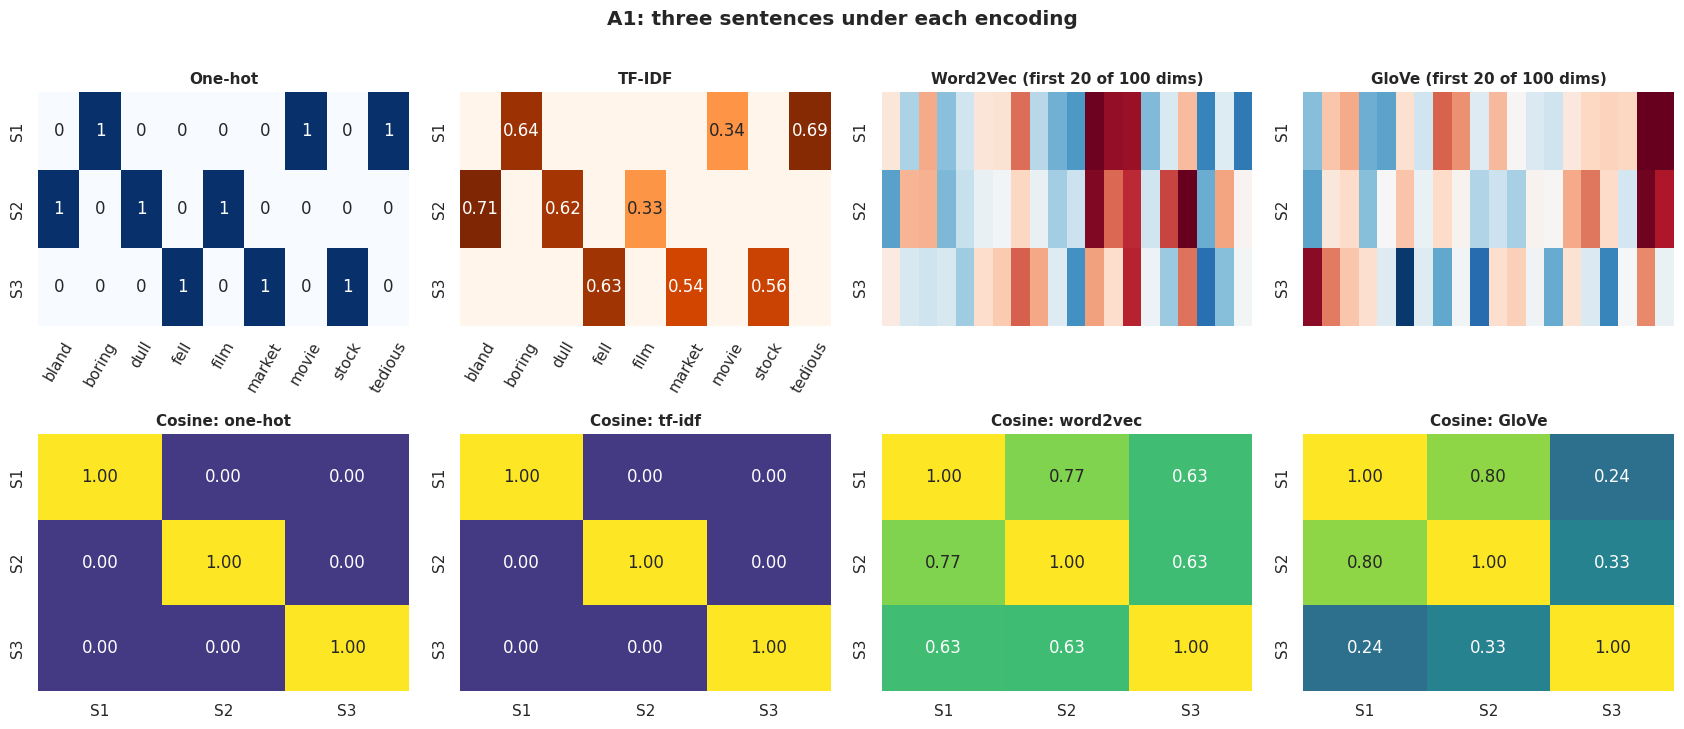

In [8]:
toy = ["a boring and tedious movie", "a dull and bland film", "the stock market fell"]
toy_tok = [tokenize(s) for s in toy]
cv = CountVectorizer(analyzer=identity, binary=True).fit(toy_tok)
vocab = cv.get_feature_names_out()
oh = cv.transform(toy_tok).toarray()
tf = TFVEC.transform(toy_tok)[:, [TFVEC.vocabulary_[w] for w in vocab]].toarray()
wv = mean_vectors(toy_tok, W2V_FULL.wv)
gv = mean_vectors(toy_tok, GLOVE)
rows = ["S1", "S2", "S3"]

fig, ax = plt.subplots(2, 4, figsize=(17, 7.2), gridspec_kw={"height_ratios": [1, 1.1]})
sns.heatmap(oh, ax=ax[0, 0], cmap="Blues", cbar=False, annot=True, fmt=".0f", xticklabels=vocab, yticklabels=rows)
ax[0, 0].set_title("One-hot")
sns.heatmap(tf, ax=ax[0, 1], cmap="Oranges", cbar=False, annot=np.where(tf > 0, np.char.mod("%.2f", tf), ""), fmt="",
            xticklabels=vocab, yticklabels=rows)
ax[0, 1].set_title("TF-IDF")
for a, M, t in [(ax[0, 2], wv, "Word2Vec (first 20 of 100 dims)"), (ax[0, 3], gv, "GloVe (first 20 of 100 dims)")]:
    sns.heatmap(M[:, :20], ax=a, cmap="RdBu_r", center=0, cbar=False, xticklabels=False, yticklabels=rows)
    a.set_title(t)
for a in ax[0, :2]:
    a.tick_params(axis="x", rotation=60)
for a, M, name in zip(ax[1], [oh, tf, wv, gv], ["one-hot", "tf-idf", "word2vec", "GloVe"]):
    C = np.nan_to_num(normalize(M) @ normalize(M).T)
    sns.heatmap(C, ax=a, vmin=-0.2, vmax=1, cmap="viridis", annot=True, fmt=".2f", cbar=False,
                xticklabels=rows, yticklabels=rows, annot_kws={"size": 12})
    a.set_title(f"Cosine: {name}")
fig.suptitle("A1: three sentences under each encoding", fontweight="bold", y=1.01)
fig.tight_layout(); save(fig, "A1_toy_encodings"); plt.show()

## C1, C2: genre of the top-10 results

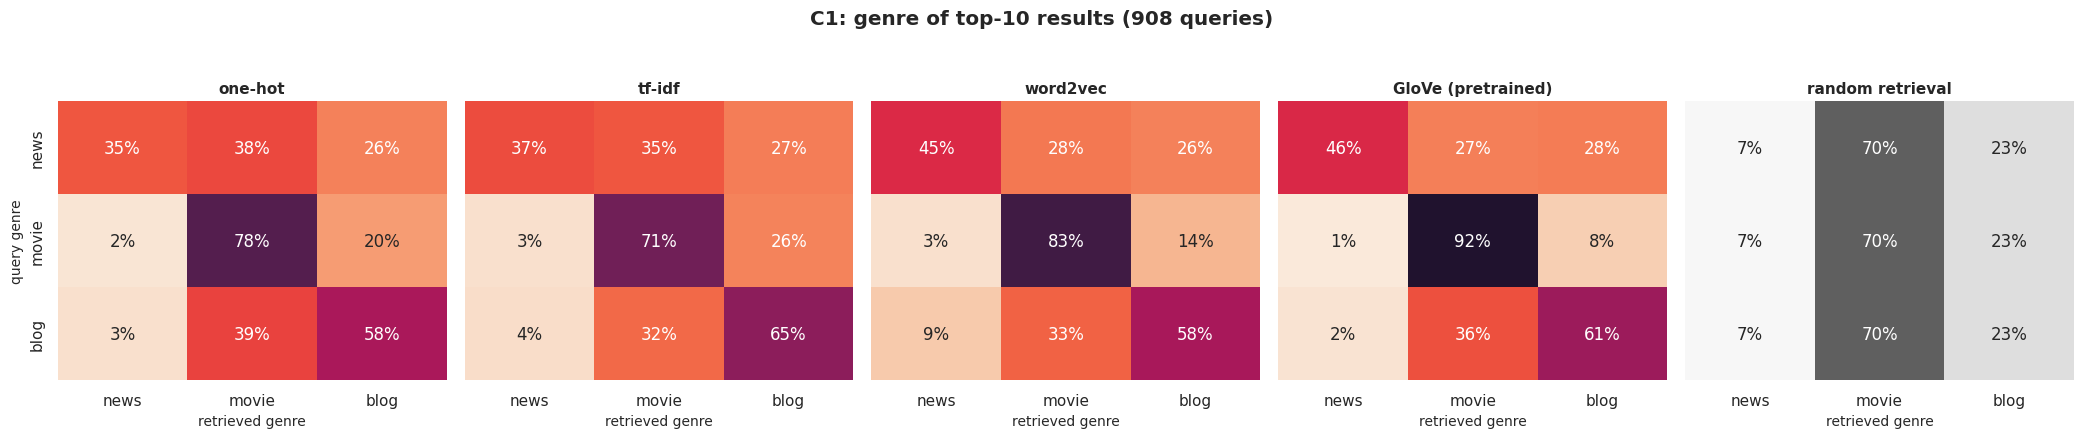

In [9]:
fig, ax = plt.subplots(1, 5, figsize=(21, 4.2))
labs = ["news", "movie", "blog"]
for a, m in zip(ax, ALL_M):
    d = PQ_FULL[PQ_FULL.method == m]
    top = RES_FULL[m]["idx"][:, :K]
    M = np.zeros((3, 3))
    for gi, g in enumerate(GENRES):
        codes = META_FULL["g"][top[(d.q_genre == g).to_numpy()]].ravel()
        M[gi] = np.bincount(codes, minlength=3) / len(codes)
    sns.heatmap(M, ax=a, annot=True, fmt=".0%", cmap="rocket_r", vmin=0, vmax=1, cbar=False,
                xticklabels=labs, yticklabels=labs if a is ax[0] else False)
    a.set_title(m)
    a.set_xlabel("retrieved genre")
ax[0].set_ylabel("query genre")
sns.heatmap(np.tile(GENRE_BASE.to_numpy(), (3, 1)), ax=ax[4], annot=True, fmt=".0%", cmap="Greys", vmin=0, vmax=1,
            cbar=False, xticklabels=labs, yticklabels=False)
ax[4].set_title("random retrieval")
ax[4].set_xlabel("retrieved genre")
fig.suptitle("C1: genre of top-10 results (908 queries)", fontweight="bold", y=1.04)
fig.tight_layout(); save(fig, "C1_genre_confusion"); plt.show()

Dashed lines are the base rates. Black dots are the 9 queries from the main notebook, the red diamond is the main notebook's 100/genre sample.

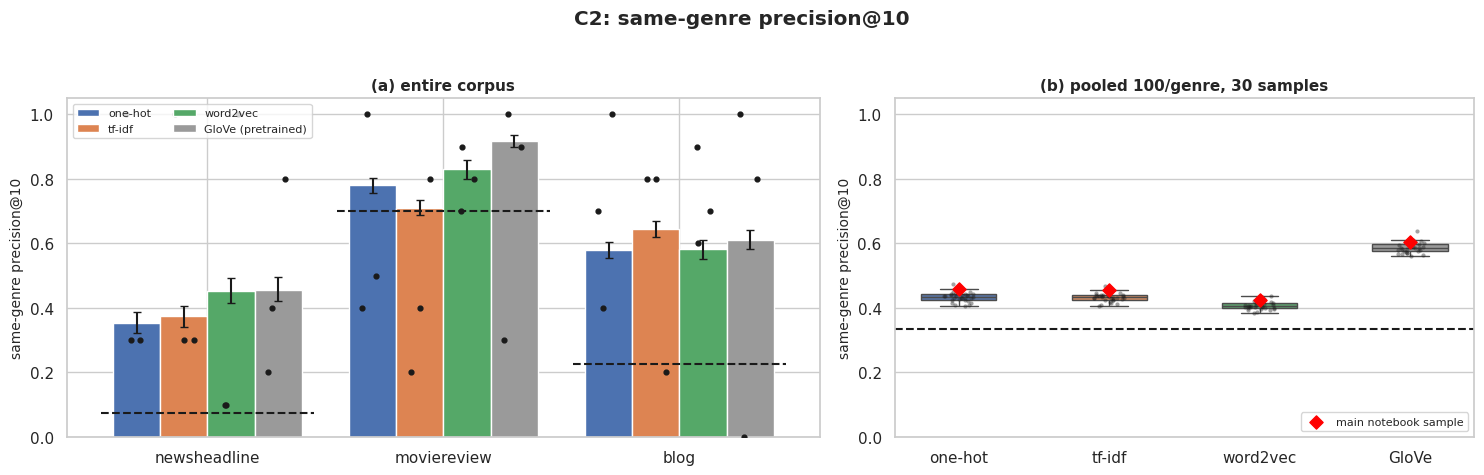

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
w = 0.2
for gi, g in enumerate(GENRES):
    for mi, m in enumerate(ALL_M):
        d = PQ_FULL[(PQ_FULL.method == m) & (PQ_FULL.q_genre == g)]
        mu, lo, hi = boot_mean(d.same_genre)
        x = gi + (mi - 1.5) * w
        ax[0].bar(x, mu, w, color=MC[m], yerr=[[mu - lo], [hi - mu]], capsize=3, label=m if gi == 0 else None)
        sv = d[d.showcase].same_genre
        ax[0].scatter(np.full(len(sv), x) + np.random.default_rng(mi).uniform(-0.05, 0.05, len(sv)), sv, color="k", s=12, zorder=3)
    ax[0].hlines(GENRE_BASE[g], gi - 0.45, gi + 0.45, color="k", ls="--", lw=1.5)
ax[0].set_xticks(range(3), GENRES)
ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("same-genre precision@10")
ax[0].set_title("(a) entire corpus")
ax[0].legend(fontsize=8, ncol=2, loc="upper left")

d = REP[REP.setting == "300 pooled"]
sns.boxplot(data=d, x="method", y="same_genre", order=ALL_M, palette=MC, ax=ax[1], width=0.5, fliersize=0)
sns.stripplot(data=d[~d.your_sample], x="method", y="same_genre", order=ALL_M, color="k", size=3, alpha=0.4, ax=ax[1])
yours = d[d.your_sample].set_index("method").reindex(ALL_M)
ax[1].scatter(range(4), yours.same_genre, marker="D", color="red", s=45, zorder=5, label="main notebook sample")
ax[1].axhline(1 / 3, color="k", ls="--", lw=1.5)
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("")
ax[1].set_xticklabels(["one-hot", "tf-idf", "word2vec", "GloVe"])
ax[1].set_ylabel("same-genre precision@10")
ax[1].set_title(f"(b) pooled 100/genre, {N_REPEATS} samples")
ax[1].legend(fontsize=8, loc="lower right")
fig.suptitle("C2: same-genre precision@10", fontweight="bold", y=1.03)
fig.tight_layout(); save(fig, "C2_same_genre_precision"); plt.show()

## E1, E2: how much training data
Mean ± SD over 3 samples per size. The star is GloVe (6B tokens).

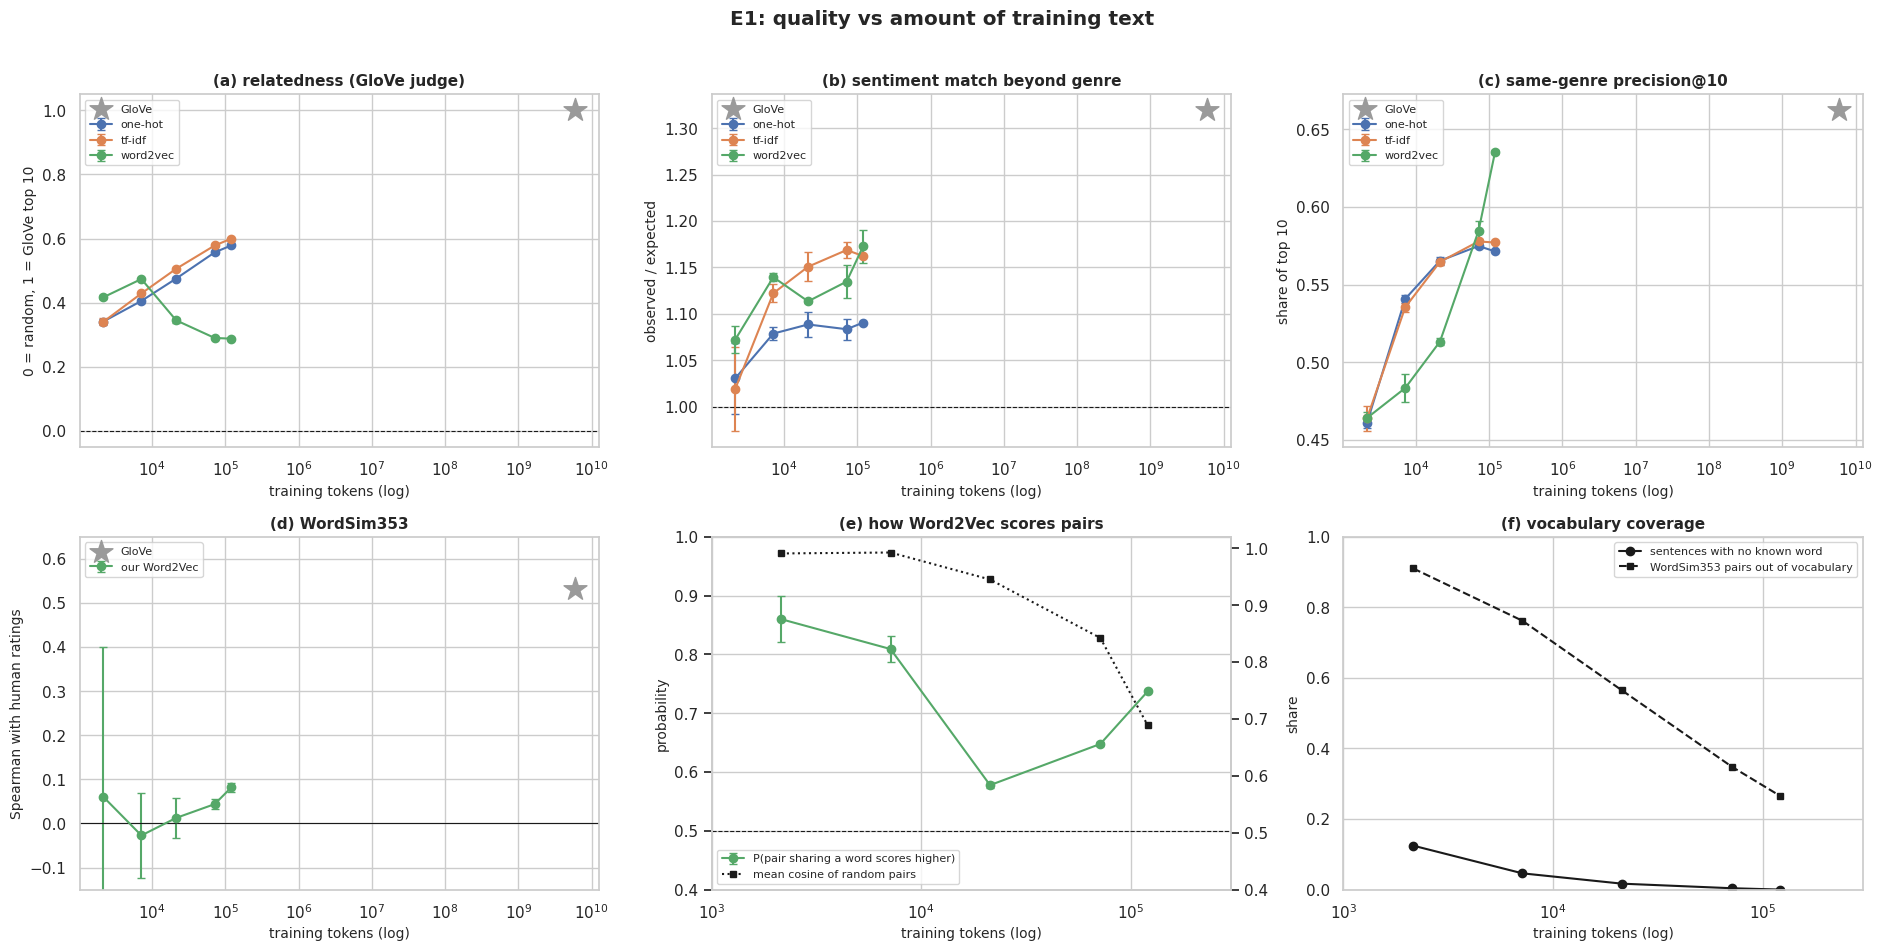

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(19, 9.4))
ax = axs.ravel()
GLOVE_TOK = 6e9
full_ref = summarize(PQ_FULL)
for a, col, title, ylab, ref_line in [
        (ax[0], "norm_judge", "(a) relatedness (GloVe judge)", "0 = random, 1 = GloVe top 10", 0),
        (ax[1], "pol_lift_adj", "(b) sentiment match beyond genre", "observed / expected", 1),
        (ax[2], "same_genre", "(c) same-genre precision@10", "share of top 10", None)]:
    for m in METHODS:
        d = LC[LC.method == m].groupby("size").agg(tok=("tokens", "mean"), mu=(col, "mean"), sd=(col, "std"))
        a.errorbar(d.tok, d.mu, yerr=d.sd, color=MC[m], marker="o", capsize=3, label=m)
    a.scatter([GLOVE_TOK], [full_ref.loc[REF, col]], color=MC[REF], marker="*", s=300, zorder=5, label="GloVe")
    if ref_line is not None:
        a.axhline(ref_line, color="k", lw=0.8, ls="--")
    a.set_title(title)
    a.set_ylabel(ylab)
    a.legend(fontsize=8)
d = LC[LC.method == "word2vec"].groupby("size").agg(tok=("tokens", "mean"), rho=("ws_spearman", "mean"),
                                                    sd=("ws_spearman", "std"), oov=("ws_oov", "mean"),
                                                    auc=("lexical_auc", "mean"), auc_sd=("lexical_auc", "std"),
                                                    cos=("mean_pair_cos", "mean"))
ax[3].errorbar(d.tok, d.rho, yerr=d.sd, color=MC["word2vec"], marker="o", capsize=3, label="our Word2Vec")
ax[3].scatter([GLOVE_TOK], [GLOVE_WS[1][0]], color=MC[REF], marker="*", s=300, zorder=5, label="GloVe")
ax[3].axhline(0, color="k", lw=0.8)
ax[3].set_ylim(-0.15, 0.65)
ax[3].set_ylabel("Spearman with human ratings")
ax[3].set_title("(d) WordSim353")
ax[3].legend(fontsize=8, loc="upper left")
ax[4].errorbar(d.tok, d.auc, yerr=d.auc_sd, color=MC["word2vec"], marker="o", capsize=3,
               label="P(pair sharing a word scores higher)")
ax[4].axhline(0.5, color="k", lw=0.8, ls="--")
ax[4].set_ylim(0.4, 1.0)
ax[4].set_ylabel("probability")
ax4b = ax[4].twinx()
ax4b.plot(d.tok, d.cos, "k:", marker="s", ms=4, label="mean cosine of random pairs")
ax4b.set_ylim(0.4, 1.02)
ax4b.grid(False)
h1, l1 = ax[4].get_legend_handles_labels()
h2, l2_ = ax4b.get_legend_handles_labels()
ax[4].legend(h1 + h2, l1 + l2_, fontsize=8, loc="lower left")
ax[4].set_title("(e) how Word2Vec scores pairs")
cov = LC[LC.method == "word2vec"].groupby("size").agg(tok=("tokens", "mean"), known=("sentences_with_known_word", "mean"))
ax[5].plot(cov.tok, 1 - cov.known, color="k", marker="o", label="sentences with no known word")
ax[5].plot(d.tok, d.oov / 100, color="k", ls="--", marker="s", ms=4, label="WordSim353 pairs out of vocabulary")
ax[5].set_ylim(0, 1)
ax[5].set_ylabel("share")
ax[5].set_title("(f) vocabulary coverage")
ax[5].legend(fontsize=8)
for a in ax:
    a.set_xscale("log")
    a.set_xlabel("training tokens (log)")
for a in ax[4:]:
    a.set_xlim(1e3, 3e5)
fig.suptitle("E1: quality vs amount of training text", fontweight="bold", y=1.01)
fig.tight_layout(); save(fig, "E1_learning_curve"); plt.show()

In [12]:
m1k = train_w2v([TL[i] for i in np.random.default_rng(0).choice(N, 1000, replace=False)])
probes = ["boring", "funny", "sad", "love", "war", "film", "music", "iraq"]
tab = {}
for name, kv in [("Word2Vec, 1k sentences", m1k.wv), ("Word2Vec, full corpus", W2V_FULL.wv), ("GloVe", GLOVE)]:
    tab[name] = [", ".join(w for w, _ in kv.most_similar(p, topn=5)) if p in kv.key_to_index else "-" for p in probes]
E2 = pd.DataFrame(tab, index=probes)
E2.to_csv(FIG_DIR / "E2_nearest_neighbours.csv")
E2

,"Word2Vec, 1k sentences","Word2Vec, full corpus",GloVe
boring,"arms, late, creepy, death, beautiful","joke, rooting, lifeless, plain, depressing","tedious, dull, bored, funny, stupid"
funny,"attention, moments, startling, dog, beautiful","thinks, amusing, goofy, consistently, cute","hilarious, amusing, weird, scary, fun"
sad,"escape, close, earth, large, vivid","sack, knockaround, count, sour, sick","sorry, awful, tragic, horrible, happy"
love,"west, cliches, flawed, theme, vividly","drunk, side, praise, triangle, americans","me, passion, my, life, dream"
war,"screenplay, white, fails, highly, beautiful","ii, current, criminal, civil, china","wars, conflict, invasion, military, occupation"
film,"boy, hoffman, prove, christmas, ages","movie, result, features, attractive, fairly","movie, films, directed, documentary, drama"
music,"largest, dance, study, existence, genre","classical, glass, philip, defines, eras","musical, songs, dance, pop, recording"
iraq,"fails, wins, bible, study, fans","troops, iraqi, iran, terror, bush","afghanistan, iraqi, baghdad, saddam, iran"


## F5: sentences vs clauses

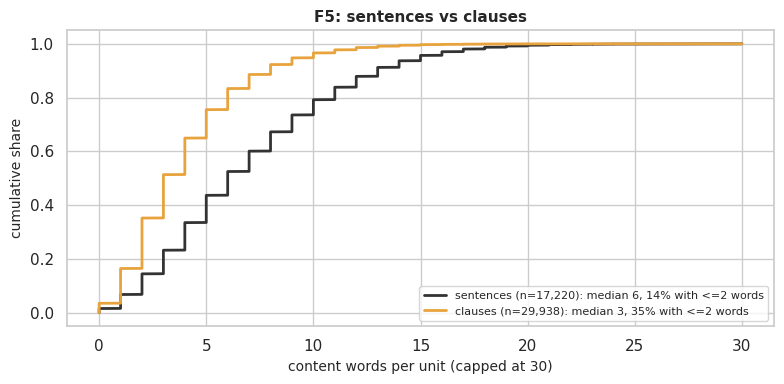

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for (name, path), c in zip([("sentences", DATA_FILE), ("clauses", CLAUSE_FILE)], ["#333333", "#E8A33D"]):
    n = load_corpus(path).text.apply(lambda s: len(tokenize(s))).to_numpy()
    v = np.sort(np.clip(n, 0, 30))
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=c, lw=2,
            label=f"{name} (n={len(n):,}): median {int(np.median(n))}, {np.mean(n <= 2):.0%} with <=2 words")
ax.set_xlabel("content words per unit (capped at 30)")
ax.set_ylabel("cumulative share")
ax.set_title("F5: sentences vs clauses")
ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "F5_sentences_vs_clauses"); plt.show()